# Synchronization Analysis With Recurrence Plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

In [2]:
# ----------------------------
# 1. Define parameters
# ----------------------------
N = 3  # number of oscillators
a, b, c = 0.2, 0.2, 5.7  # Rössler parameters
epsilon = 0.01  # coupling strength
T = 100  # integration time
dt = 0.1

# Adjacency matrix (all-to-all coupling)
A = np.ones((N, N)) - np.eye(N)  # no self-coupling

# ----------------------------
# 2. Define the coupled ODE
# ----------------------------
def rossler_coupled(t, X):
    """
    X is a flattened vector [x1, y1, z1, x2, y2, z2, ..., xN, yN, zN]
    """
    X = X.reshape(N, 3)
    dX = np.zeros_like(X)
    
    for i in range(N):
        xi, yi, zi = X[i]
        # intrinsic Rössler dynamics
        dx = -yi - zi
        dy = xi + a*yi
        dz = b + zi*(xi - c)
        
        # coupling: sum_j A[i,j]*(x_j - x_i)
        coupling_term = epsilon * np.sum(A[i] * (X[:,0] - xi))
        dx += coupling_term
        
        dX[i] = [dx, dy, dz]
    
    return dX.flatten()

# ----------------------------
# 3. Initial conditions
# ----------------------------
np.random.seed(42)
X0 = np.random.rand(N*3)

# ----------------------------
# 4. Solve numerically
# ----------------------------
t_span = (0, T)
t_eval = np.arange(0, T, dt)

sol = solve_ivp(rossler_coupled, t_span, X0, t_eval=t_eval, method='RK45')

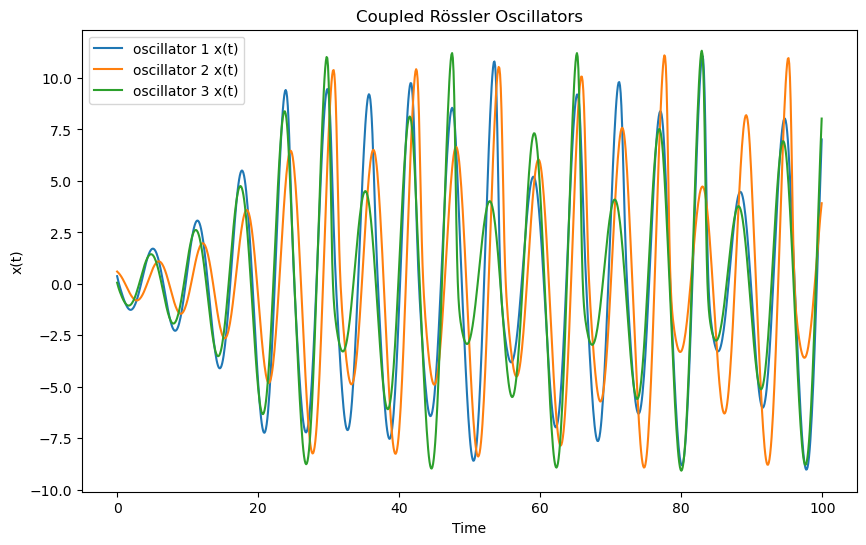

In [3]:
# ----------------------------
# 5. Plot results
# ----------------------------
plt.figure(figsize=(10,6))
for i in range(N):
    plt.plot(sol.t, sol.y[i*3], label=f'oscillator {i+1} x(t)')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Coupled Rössler Oscillators')
plt.legend()
plt.show()

# Recurrence Analysis

In [4]:
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot

In [5]:
R = RecurrencePlot(sol.y[0], dim=3, tau=2, recurrence_rate=0.05)


Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


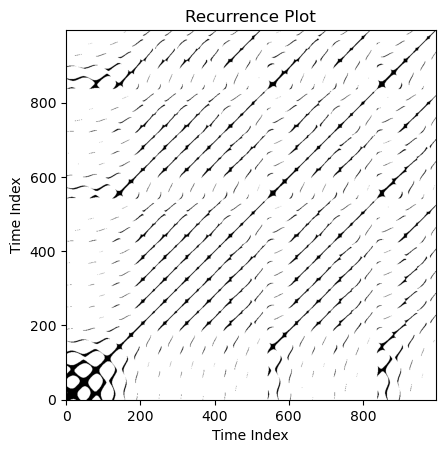

In [6]:
Rmat = R.recurrence_matrix()

plt.imshow(Rmat, origin='lower', cmap='binary')
plt.title('Recurrence Plot')
plt.xlabel('Time Index')
plt.ylabel('Time Index')
plt.show()

In [8]:
from pyunicorn.timeseries.cross_recurrence_plot import CrossRecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

In [16]:
R_C = CrossRecurrencePlot(sol.y[0], sol.y[3], dim=3, tau=2, recurrence_rate=0.05)
R_J = JointRecurrencePlot(sol.y[0], sol.y[3], dim=(3,5), tau=(2,1),
    recurrence_rate=(0.05,0.04))

Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating the supremum distance matrix...


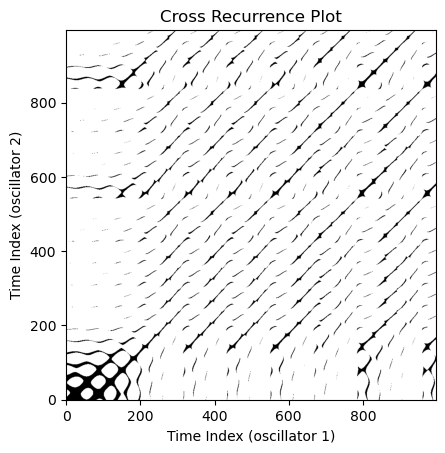

In [18]:
RMat_C = R_C.recurrence_matrix()

plt.imshow(RMat_C, origin='lower', cmap='binary')
plt.title('Cross Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

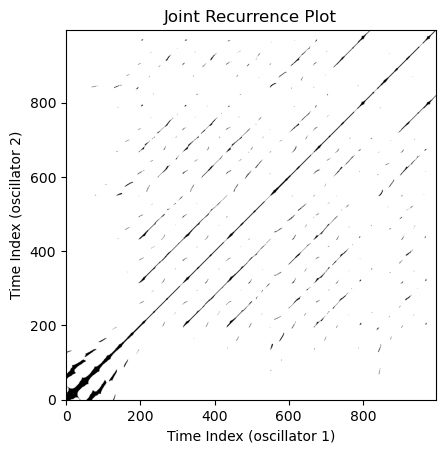

In [19]:
RMat_J = R_J.recurrence_matrix()

plt.imshow(RMat_J, origin='lower', cmap='binary')
plt.title('Joint Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()